<a href="https://colab.research.google.com/github/krupnitskyirostyslav/Traffic-Sales-Analysis/blob/main/Traffic_%26_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Connectin to Google cloud and creating DataFrame using SQL request in Google cloud project

In [ ]:
!pip install --upgrade google-cloud-bigquery

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd

In [ ]:
auth.authenticate_user()

In [ ]:
client = bigquery.Client(project="data-analytics-mate")

In [ ]:
query = """
with

session_info as (
  select
        s.date,
        s.ga_session_id,
        sp.continent,
        sp.country,
        sp.device,
        sp.browser,
        sp.mobile_model_name,
        sp.operating_system,
        sp.language,
        sp.name as traffic_source,
        sp.channel as traffic_channel
  from `DA.session` s
  left join `DA.session_params` sp
  on s.ga_session_id = sp.ga_session_id
),

account_info as (
  select
        acs.ga_session_id,
        ac.id as account_id,
        ac.is_verified,
        ac.is_unsubscribed
  from `DA.account_session` acs
  left join `DA.account` ac
  on acs.account_id = ac.id
),

order_info as (
  select
        o.ga_session_id,
        p.category as item_category,
        p.name as item_name,
        p.price,
        p.short_description
from `DA.order` o
left join `DA.product` p
on o.item_id = p.item_id
)

select
      si.date,
      si.ga_session_id as session_id,
      si.continent,
      si.country,
      si.device,
      si.browser,
      si.mobile_model_name,
      si.operating_system,
      si.language,
      si.traffic_source,
      si.traffic_channel,
      ai.account_id,
      ai.is_verified,
      ai.is_unsubscribed,
      oi.item_category,
      oi.item_name,
      oi.price,
      oi.short_description
from session_info si
left join account_info ai
on si.ga_session_id = ai.ga_session_id
left join order_info oi
on si.ga_session_id = oi.ga_session_id
"""

In [ ]:
query_job = client.query(query) # performance of the query
results = query_job.result() # waiting the query to finish
df = results.to_dataframe()

# 2. Overview of DataFrame

### Data modifications

In [ ]:
df['is_verified'] = df['is_verified'].astype('category')
df['is_unsubscribed'] = df['is_unsubscribed'].astype('category')
cols_with_value = df.columns[df.isin(["<Other>"]).any()]
df[cols_with_value] = df[cols_with_value].replace('<Other>', 'Other')
df["language"] = df["language"].fillna("Other")


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   date               349545 non-null  dbdate  
 1   session_id         349545 non-null  Int64   
 2   continent          349545 non-null  object  
 3   country            349545 non-null  object  
 4   device             349545 non-null  object  
 5   browser            349545 non-null  object  
 6   mobile_model_name  349545 non-null  object  
 7   operating_system   349545 non-null  object  
 8   language           349545 non-null  object  
 9   traffic_source     349545 non-null  object  
 10  traffic_channel    349545 non-null  object  
 11  account_id         27945 non-null   Int64   
 12  is_verified        27945 non-null   category
 13  is_unsubscribed    27945 non-null   category
 14  item_category      33538 non-null   object  
 15  item_name          33538 non-null 

In [ ]:
unique_sessin_count = df['session_id'].nunique()
print(f'Unique sessions count: {unique_sessin_count}')
print(f"Period of time from: {df['date'].min()} to {df['date'].max()}")


Unique sessions count: 349545
Period of time from: 2020-11-01 to 2021-01-31


###In resulted DataFrame we have 18 columns in total
* **3 numerical**: "session_id", (Int64), "account_id" (Int64), "price" (float64)
* **2 categorical**: "is_verified", "Is_unsubscribed"
* **1 date column**: "date"
* **12 object column**: "continent",	"country",	"device",	"browser", "mobile_model_name",	"operating_system",	"language",	"traffic_source",	"traffic_channel", "item_category",	"item_name", "short_description".

###Period of time from: 2020-11-01 to 2021-01-31

###It has Null values in some sections
* **"account_id", "is_verified", "is_unsubscribed"** has Null values because it only describes sesions in which account subscription was made.
* **"item_category", "item_name", "price", "short_description"** has Null values because it only describes sesions in which order was made

In [ ]:
df.head()

,date,session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,traffic_channel,account_id,is_verified,is_unsubscribed,item_category,item_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,Other,Paid Search,<NA>,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,<NA>,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,Other,Web,zh,(direct),Direct,<NA>,NaN,NaN,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,Other,Android,es-es,(direct),Direct,<NA>,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,<NA>,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


1. **date**                - Session date
2. **session_id**          - User session ID
3. **continent**           - The continent in which the user's country is located
4. **country**             - User country by IP
5. **device**              - Device type (desktop, mobile, tablet)
6. **browser**             - Browser name
7. **mobile_model_name**   - Mobile device model name  
8. **operating_system**    - Device operating system
9. **language**            - Browser language
10. **traffic_source**     - Traffic source ID
11. **traffic_channel**    - Total traffic channel
12. **account_id**         - Unique subscriber identifier (if NULL - user in this session is not registered)
13. **is_verified**        - Whether the user has confirmed their email address (0 - not confirmed, 1 - confirmed)
14. **is_unsubscribed**    - Whether the user has unsubscribed from the newsletter (0 - not unsubscribed, 1 - unsubscribed)
15. **item_category**      - Product Category
16. **item_name**          - Product Name
17. **price**              - Price, USD
18. **short_description**  - Short Product Description

#3. General analysis

### Calculations

In [ ]:
top5_sales_countries = df.groupby(['country'])['price'].sum().nlargest(5)
top3_sales_continents = df.groupby(['continent'])['price'].sum().nlargest(3)
top5_orders_countries = df.groupby(['country'])['price'].count().nlargest(5)
top3_orders_continents = df.groupby(['continent'])['price'].count().nlargest(5)

print(f"Top 5 countries by sales: {top5_sales_countries}")
print(f"\nTop 3 continents by sales: {top3_sales_continents}")
print(f"\nTop 5 countries by orders: {top5_orders_countries}")
print(f"\nTop 3 continents by orders: {top3_orders_continents}")

Top 5 countries by sales: country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Name: price, dtype: float64

Top 3 continents by sales: continent
Americas    17665280.0
Asia         7601298.3
Europe       5934624.2
Name: price, dtype: float64

Top 5 countries by orders: country
United States     14673
India              3029
Canada             2560
United Kingdom     1029
France              678
Name: price, dtype: int64

Top 3 continents by orders: continent
Americas    18553
Asia         7950
Europe       6261
Oceania       364
Africa        339
Name: price, dtype: int64


In [ ]:
top10_categories = df.groupby(['item_category'])['price'].sum().nlargest(10)
top10_cetegories_in_top_country = df[df['country'] == top5_sales_countries.index[0]].groupby(['item_category'])['price'].sum().nlargest(10)

print(f"Top 10 categories by sales: {top10_categories}")
print(f"\nTop 10 categories in top country by sales: {top10_cetegories_in_top_country}")

Top 10 categories by sales: item_category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children's furniture                 467697.0
Name: price, dtype: float64

Top 10 categories in top country by sales: item_category
Sofas & armchairs                   3707144.5
Chairs                              2619773.8
Beds                                2213058.0
Bookcases & shelving units          1567606.9
Cabinets & cupboards                 994545.5
Outdoor furniture                    929245.2
Tables & desks                       777865.0
Chests of drawers & drawer units     382388.0
Bar furniture                        330805.

In [ ]:
device_type_sales = (
    df.groupby("device")["price"].sum()
    .pipe(lambda s: s / s.sum() * 100)
)
print(f"Device type by sales: {device_type_sales}")

Device type by sales: device
desktop    59.002245
mobile     38.734924
tablet      2.262831
Name: price, dtype: float64


In [ ]:
registered_account_data = df[df['account_id'].notna()]
perc = registered_account_data['session_id'].nunique() / df['session_id'].nunique() * 100

verified_proportion = registered_account_data['is_verified'].value_counts(normalize=True).get(1) * 100
unsubscribed_proportion = registered_account_data['is_unsubscribed'].value_counts(normalize=True).get(1) * 100

print(f"Proportion of accounts with verified email: {verified_proportion:.0f}%")
print(f"Proportion of accounts that is unsubscribed from the newsletters: {unsubscribed_proportion:.0f}%")
print(f"Proportion of sessions with registered accounts: {perc:.0f}%")

Proportion of accounts with verified email: 72%
Proportion of accounts that is unsubscribed from the newsletters: 17%
Proportion of sessions with registered accounts: 8%


In [ ]:
subscribed_sales = df[df['is_unsubscribed'] == 0]['price'].sum()
unsubscribed_sales = df[df['is_unsubscribed'] == 1]['price'].sum()

avg_subscribed_sales = df[df['is_unsubscribed'] == 0]['price'].sum() / df[df['is_unsubscribed'] == 0]['price'].count()
avg_unsubscribed_sales = df[df['is_unsubscribed'] == 1]['price'].sum() / df[df['is_unsubscribed'] == 1]['price'].count()

print(f"Subscribed sales: {subscribed_sales}, Unsubscribed sales: {unsubscribed_sales}")
print(f"Average subscribed sales: {avg_subscribed_sales}, Average unsubscribed sales: {avg_unsubscribed_sales}")

Subscribed sales: 2150796.9, Unsubscribed sales: 431721.6
Average subscribed sales: 921.5068123393315, Average unsubscribed sales: 965.8201342281878


In [ ]:
top10_registered_countries = df.groupby(['country'])['account_id'].count().nlargest(5)
top10_registered_countries

,account_id
country,
United States,12384
India,2687
Canada,2067
United Kingdom,859
France,553


### Summary
* As we can see **Americas ans Asia (especially United States and India)** are our biggest customers with the biggest number of orders and sales.
* The most popular categories worldwide are: **Sofas & armchairs, Chairs, Beds**
The country with the highest sales shows the same demand pattern.
This suggests that the largest market is a key driver of global sales and has consumer preferences that align well with global trends.
* 59% of site users use Desktop, 39% - Mobile devices, 2% use Tablets.
* 72% of registered users have verified their email
* 17% accounts have unsubscribed from the newsletters
* 83% of users are subscribed to newsletters, and they generate 83% of total revenue.
This indicates that subscribers purchase more frequently, although their average order value is slightly lower than that of unsubscribed users.
Unsubscribed users represent only 17% of the customer base but have a higher average basket size, suggesting they behave as occasional but higher‑value shoppers.
Encouraging these users to subscribe could increase their purchase frequency and overall revenue contribution.




# 4. Sales dynamic analysis


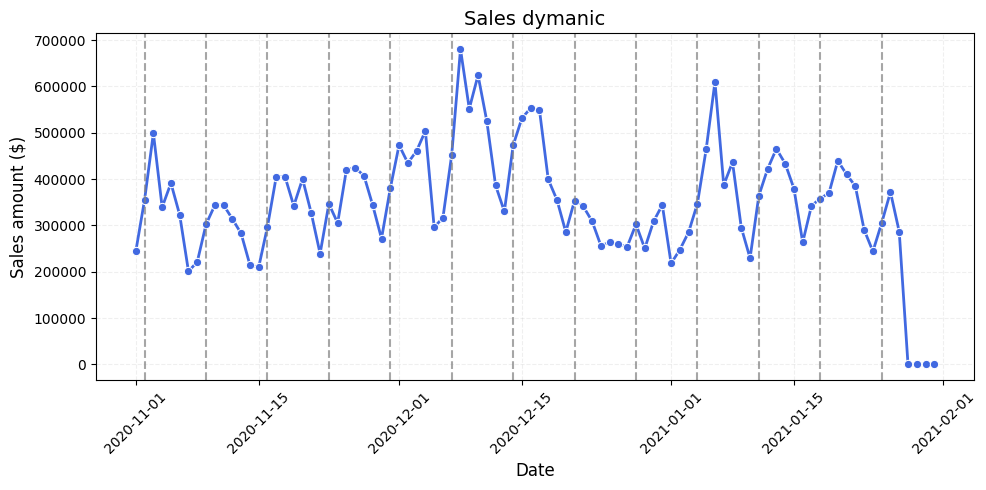

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

profit_by_date_df = (
    df.groupby('date')['price'].sum().reset_index()
)
profit_by_date_df['date'] = pd.to_datetime(profit_by_date_df['date'])
profit_by_date_df['weekday'] = profit_by_date_df['date'].dt.day_name()

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=profit_by_date_df,
    x='date',
    y='price',
    marker='o',
    color='royalblue',
    linewidth=2
)

# Highlight Mondays
for date in profit_by_date_df[profit_by_date_df['weekday'] == 'Monday']['date']:
    plt.axvline(x=date, color='grey', linestyle='--', alpha=0.7)

plt.title('Sales dymanic', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales amount ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Sales remain relatively stable throughout the period, fluctuating within a similar range (200-500k) without a clear long‑term trend.

A clear weekly seasonality is visible: sales typically peak on Tuesday and Wednesday, remain moderate on Monday, and decline toward the weekend, reaching the lowest levels on Saturday and Sunday.

Several noticeable spikes occur around mid‑November, early December, and early January, likely reflecting promotional or seasonal events. Most likely spike in December describe present  shopping before Christmas.

At the end of the period, sales drop sharply to near zero, which may indicate missing data or the end of the reporting window.


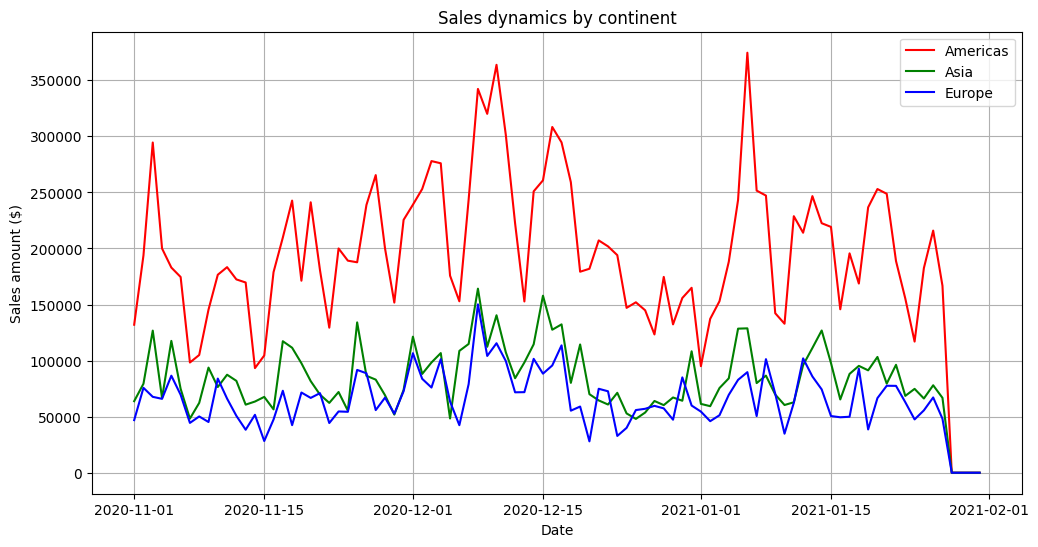

In [ ]:
# Aggregate sales by date and continent
sales_by_continent = (
    df.groupby(['date', 'continent'])['price'].sum().reset_index()
)

plt.figure(figsize=(12,6))

continents = ['Americas', 'Asia', 'Europe']
colors = {'Americas': 'red', 'Asia': 'green', 'Europe': 'blue'}

for cont in continents:
    subset = sales_by_continent[sales_by_continent['continent'] == cont]
    plt.plot(subset['date'], subset['price'], label=cont, color=colors[cont])

plt.title('Sales dynamics by continent')
plt.xlabel('Date')
plt.ylabel('Sales amount ($)')
plt.legend()
plt.grid(True)
plt.show()

America dominates sales and drives the bulk of global growth.
Europe provides a stable average level of sales without sharp fluctuations.
Asia has the lowest volumes, but shows a smooth and predictable growth.
The different colors in the graph clearly show the differences between continents and make it easy to compare their contribution to overall sales.

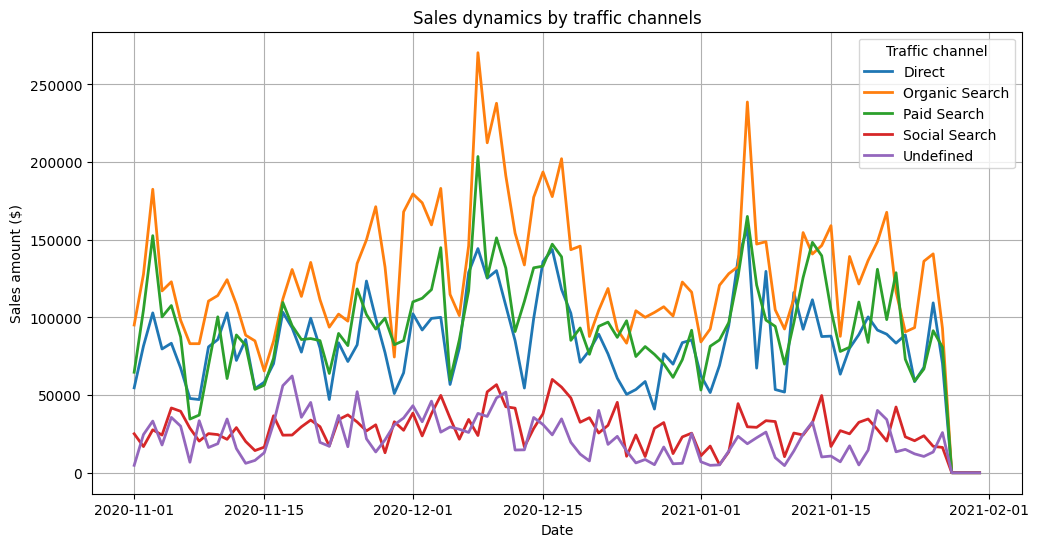

In [ ]:
# Aggregate sales by date and traffic channel
sales_by_channel = (
    df.groupby(['date', 'traffic_channel'])['price'].sum().reset_index()
)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=sales_by_channel,
    x='date',
    y='price',
    hue='traffic_channel',
    palette='tab10',
    linewidth=2
)

plt.title('Sales dynamics by traffic channels')
plt.xlabel('Date')
plt.ylabel('Sales amount ($)')
plt.grid(True)
plt.legend(title='Traffic channel')
plt.show()

Organic Search is the key sales channel, providing the highest peaks and the largest contribution to the overall dynamics. Direct and Paid Search show average sales levels with a similar structure of fluctuations, indicating a combination of loyal audience and advertising activities. Social Search and Undefined have minimal impact on overall sales. Visualization with different colors clearly shows the differences between channels and makes it easy to compare their performance over time.

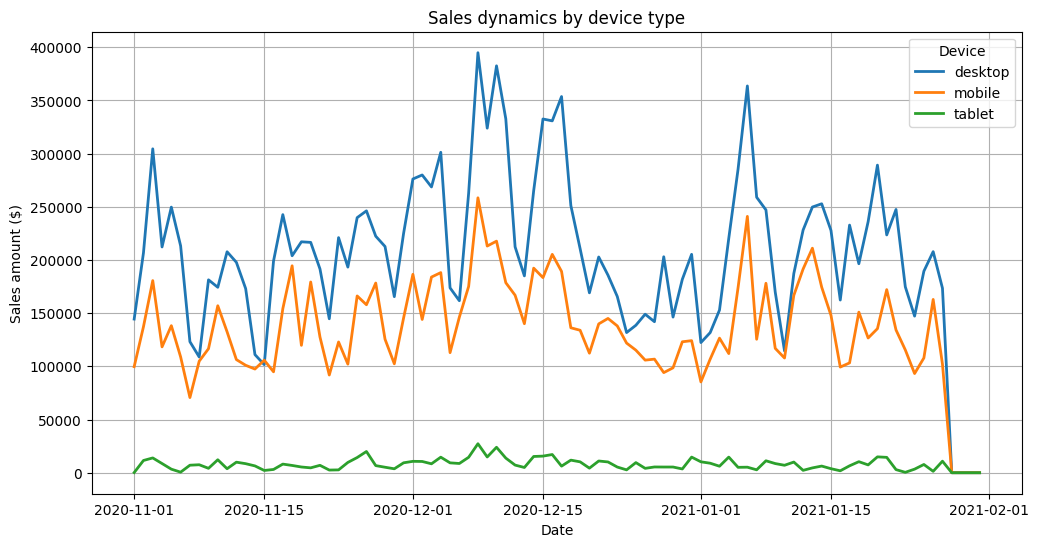

In [ ]:
# Aggregate sales by date and device type
sales_by_device = (
    df.groupby(['date', 'device'])['price'].sum().reset_index()
)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=sales_by_device,
    x='date',
    y='price',
    hue='device',
    palette='tab10',
    linewidth=2
)

plt.title('Sales dynamics by device type')
plt.xlabel('Date')
plt.ylabel('Sales amount ($)')
plt.grid(True)
plt.legend(title='Device')
plt.show()


Sales vary significantly by device type. Desktop is the key revenue driver and shows the highest activity and strongest peaks. Mobile provides a stable but lower level of sales, repeating the general seasonality. Tablet has a minimal impact on the overall dynamics.
The visualization with different colors clearly shows that the main revenue is generated by desktop users, while the mobile channel plays a supporting role.


#5. Pivot Tables


In [ ]:
pivot_session_in_device_channel = pd.pivot_table(
    df,
    values = 'session_id',
    index = 'traffic_channel',
    columns = 'device',
    aggfunc = 'size'

)
pivot_session_in_device_channel

device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


Organic Search is the most powerful channel across all devices.
Direct and Paid Search form a strong middle segment that provides stable traffic.
Desktop is the key device that generates the largest number of sessions in each channel.
Mobile is important, but less converting.
Tablet has minimal impact.
The traffic structure shows that the main valuable traffic comes from organic and desktop users.

In [ ]:

# Find top-10 categories by total sales
top_categories = (
    df.groupby('item_category')['price']
    .sum()
    .nlargest(10)
    .index
)

# Find top-5 countries by total sales
top_countries = (
    df.groupby('country')['price']
    .sum()
    .nlargest(5)
    .index
)

# Filter dataset to only top categories and top countries
df_filtered = df[
    df['item_category'].isin(top_categories) &
    df['country'].isin(top_countries)
]

# Create pivot table
pivot_sales = pd.pivot_table(
    df_filtered,
    values='price',
    index='item_category',
    columns='country',
    aggfunc='sum',
    fill_value=0
)

pivot_sales.sort_values(by='United States', ascending=False, inplace=True)
pivot_sales

country,Canada,France,India,United Kingdom,United States
item_category,,,,,
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Tables & desks,132678.0,42299.0,186157.5,49374.0,777865.0
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0


In [ ]:
# Create pivot table
pivot_subs = pd.pivot_table(
    df,
    values='price',
    index='item_category',
    columns='is_unsubscribed',
    aggfunc='sum',
    fill_value=0
)

pivot_subs.sort_values(by=0, ascending=False, inplace=True)
pivot_subs

/tmp/ipykernel_17134/2717263560.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_subs = pd.pivot_table(


is_unsubscribed,0,1
item_category,,
Sofas & armchairs,552157.0,108299.0
Chairs,439766.2,100190.0
Beds,332627.0,62078.0
Bookcases & shelving units,223777.0,51732.6
Cabinets & cupboards,189591.5,26278.0
Outdoor furniture,128107.2,15587.0
Tables & desks,124069.0,29464.0
Chests of drawers & drawer units,45953.0,12035.0
Bar furniture,42410.0,8604.0


Subscribed users bring 4-6 times more sales in all categories.
The largest contribution is in expensive categories (sofas, armchairs, beds).
Unsubscribed users buy less often and less, mainly in the mid-price segment.
Email marketing is a critical channel for supporting sales in key categories.

#6. Statistical analysis of relationships.

##Sessions-Sales correlation

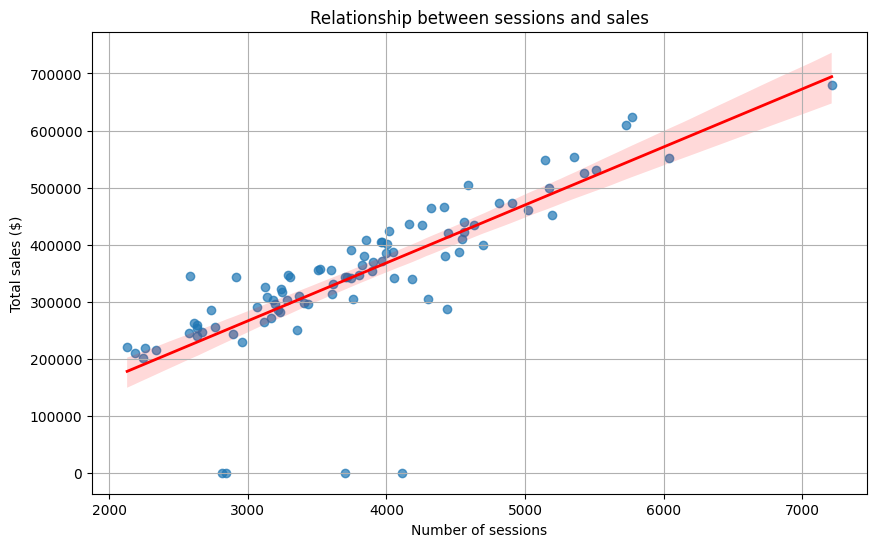

In [ ]:
# Sessions per date
sessions_by_date = (
    df.groupby('date')['session_id']
      .nunique()
      .reset_index(name='sessions')
)

# Sales per date
sales_by_date = (
    df.groupby('date')['price']
      .sum()
      .reset_index(name='sales')
)

# Merge into one dataframe
daily_metrics = pd.merge(sessions_by_date, sales_by_date, on='date')
daily_metrics

plt.figure(figsize=(10,6))

sns.regplot(
    data=daily_metrics,
    x='sessions',
    y='sales',
    scatter_kws={'alpha':0.7},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title('Relationship between sessions and sales')
plt.xlabel('Number of sessions')
plt.ylabel('Total sales ($)')
plt.grid(True)
plt.show()


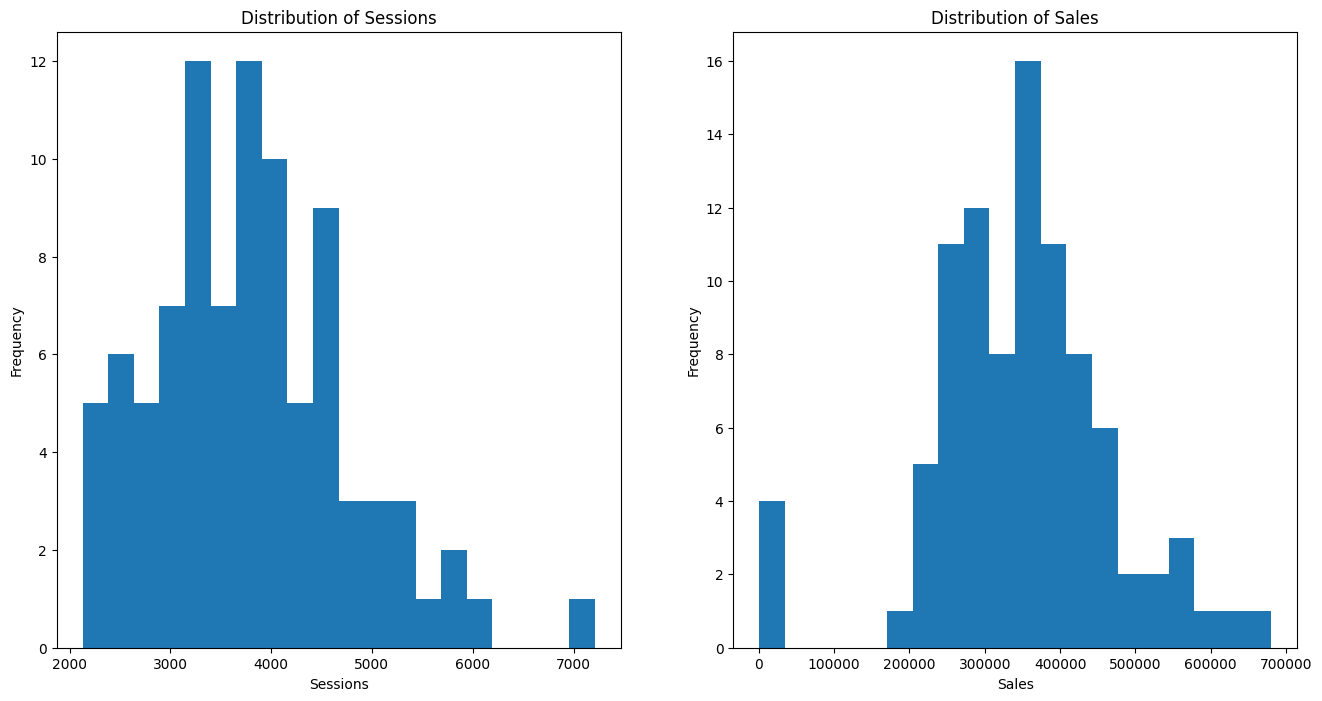

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(16, 8))

ax[0].hist(daily_metrics['sessions'], bins=20,)
ax[0].set_title('Distribution of Sessions')
ax[0].set_xlabel('Sessions')
ax[0].set_ylabel('Frequency')

ax[1].hist(daily_metrics['sales'], bins=20)
ax[1].set_title('Distribution of Sales')
ax[1].set_xlabel('Sales')
ax[1].set_ylabel('Frequency')
plt.show()

Histograms show asymmetrical, right-skewed distributions. This means that:

* The data are not normally distributed
* Spearman is a better fit because it does not require normality

In [ ]:
import scipy.stats as stats

session_sales_spearman_corr, p_value = stats.spearmanr(daily_metrics['sessions'], daily_metrics['sales'])
print(f"Spearman correlation coefficient: {session_sales_spearman_corr}, p-value: {p_value}")

Spearman correlation coefficient: 0.8653062174563682, p-value: 9.755923586156614e-29


Correlation is moderte positive and the relationship is statistically significant. This means that the bigger number of sessions is, the bigger sales are likely to be done

## Correlation of top 3 continents by sales


In [ ]:
top3_sales_continents_index = top3_sales_continents.index
df_top3_sales_continents = df[df['continent'].isin(top3_sales_continents_index)]

daily_sales_by_top3_continents = (
    df_top3_sales_continents.groupby(['date', 'continent'])['price']
    .sum()
    .reset_index()
)

pivot_daily_sales_by_top3_continents = pd.pivot_table(
    daily_sales_by_top3_continents,
    values='price',
    index='date',
    columns='continent'
)

pivot_daily_sales_by_top3_continents

continent,Americas,Asia,Europe
date,,,
2020-11-01,132002.5,63823.0,46908.0
2020-11-02,193861.0,79370.0,75710.8
2020-11-03,294529.8,126737.8,67692.0
2020-11-04,200009.5,66602.0,65915.0
2020-11-05,182988.2,117608.4,86540.0
...,...,...,...
2021-01-27,166735.5,66783.1,48156.1
2021-01-28,0.0,0.0,0.0
2021-01-29,0.0,0.0,0.0


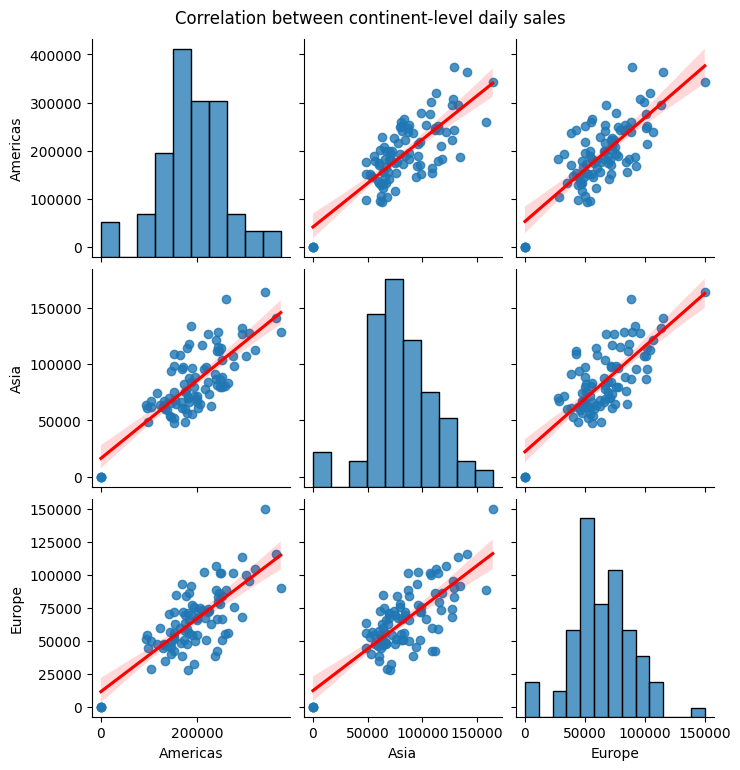

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    pivot_daily_sales_by_top3_continents,
    kind='reg',
    plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Correlation between continent-level daily sales', y=1.02)
plt.show()

In [ ]:
corr_matrix = pivot_daily_sales_by_top3_continents.corr()
corr_matrix

continent,Americas,Asia,Europe
continent,,,
Americas,1.000000,0.792025,0.770586
Asia,0.792025,1.000000,0.768427
Europe,0.770586,0.768427,1.000000


In [ ]:
from scipy.stats import pearsonr

continents = pivot_daily_sales_by_top3_continents.columns
results = {}

for c1 in continents:
    for c2 in continents:
        if c1 < c2:
            coef, p = pearsonr(pivot_daily_sales_by_top3_continents[c1], pivot_daily_sales_by_top3_continents[c2])
            results[(c1, c2)] = {'corr_coef': coef, 'p_value': p}

results

{('Americas', 'Asia'): {'corr_coef': np.float64(0.7920245629479414),
  'p_value': np.float64(5.409189396197475e-21)},
 ('Americas', 'Europe'): {'corr_coef': np.float64(0.7705864582886499),
  'p_value': np.float64(2.6714492240629956e-19)},
 ('Asia', 'Europe'): {'corr_coef': np.float64(0.7684273823164164),
  'p_value': np.float64(3.8649460090531196e-19)}}

Sales in the top 3 continents are highly correlated (0.76–0.79), and these correlations are statistically significant with extremely small p-values. This suggests that global factors—seasonality, marketing campaigns, holiday periods—affect all markets simultaneously. The Americas are the largest and most influential market, but Europe and Asia show very similar sales dynamics.

##Correlation of sales channels

In [ ]:
daily_sales_by_channel = (
    df.groupby(['date', 'traffic_channel'])['price']
      .sum()
      .reset_index()
)

pivot_daily_sales_by_channel = daily_sales_by_channel.pivot(
    index='date',
    columns='traffic_channel',
    values='price'
)

pivot_daily_sales_by_channel

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
date,,,,,
2020-11-01,54669.5,95112.0,64688.0,25078.0,4745.0
2020-11-02,81561.5,127746.5,104780.8,16843.0,24575.0
2020-11-03,102909.5,182521.9,152641.3,27652.5,33254.4
2020-11-04,79683.6,117067.1,100332.0,24257.4,17847.0
2020-11-05,83367.6,122938.4,107648.0,41693.2,35629.4
...,...,...,...,...,...
2021-01-27,70423.1,92921.1,80869.5,16282.0,25845.0
2021-01-28,0.0,0.0,0.0,0.0,0.0
2021-01-29,0.0,0.0,0.0,0.0,0.0


In [ ]:
corr_matrix = pivot_daily_sales_by_channel.corr()
corr_matrix

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
traffic_channel,,,,,
Direct,1.000000,0.837833,0.814072,0.604060,0.517505
Organic Search,0.837833,1.000000,0.870086,0.583117,0.526068
Paid Search,0.814072,0.870086,1.000000,0.596428,0.521961
Social Search,0.604060,0.583117,0.596428,1.000000,0.455126
Undefined,0.517505,0.526068,0.521961,0.455126,1.000000


In [ ]:
from scipy.stats import pearsonr

channels = pivot_daily_sales_by_channel.columns
results = {}

for c1 in channels:
    for c2 in channels:
        if c1 < c2:
            coef, p = pearsonr(
                pivot_daily_sales_by_channel[c1],
                pivot_daily_sales_by_channel[c2]
            )
            coef = coef.round(2)

            results[(c1, c2)] = {'Coefficient': coef, 'p_value': p}

results


{('Direct', 'Organic Search'): {'Coefficient': np.float64(0.84),
  'p_value': np.float64(2.1904196603645366e-25)},
 ('Direct', 'Paid Search'): {'Coefficient': np.float64(0.81),
  'p_value': np.float64(5.896434878977516e-23)},
 ('Direct', 'Social Search'): {'Coefficient': np.float64(0.6),
  'p_value': np.float64(1.831889246946262e-10)},
 ('Direct', 'Undefined'): {'Coefficient': np.float64(0.52),
  'p_value': np.float64(1.2754357002002653e-07)},
 ('Organic Search', 'Paid Search'): {'Coefficient': np.float64(0.87),
  'p_value': np.float64(2.1420029219324783e-29)},
 ('Organic Search', 'Social Search'): {'Coefficient': np.float64(0.58),
  'p_value': np.float64(1.0661924301883206e-09)},
 ('Organic Search', 'Undefined'): {'Coefficient': np.float64(0.53),
  'p_value': np.float64(7.228214166055068e-08)},
 ('Paid Search', 'Social Search'): {'Coefficient': np.float64(0.6),
  'p_value': np.float64(3.5322844619049755e-10)},
 ('Paid Search', 'Undefined'): {'Coefficient': np.float64(0.52),
  'p_value

Sales across traffic channels have a strong positive correlation (0.8+ across major channels) and statistically significant relationships. This suggests that global marketing campaigns, seasonality, and user behavior are impacting all channels simultaneously.
The primary cluster—Direct, Organic Search, Paid Search—is key to predicting sales.
Social and uncategorized channels have a weaker, but still significant, correlation.

- Direct, Organic Search, and Paid Search channels form a single cluster - they move in sync, responding to the same marketing factors.
- Social Search - a separate, more independent channel that can be useful for reaching new audiences.
- Undefined - a technical or noise channel that has no significant impact

##Correlation of top 5 categories by sales

In [ ]:
top5_categories = (
    df.groupby('item_category')['price'].sum().nlargest(5).index
)
print(top5_categories)


Index(['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units',
       'Cabinets & cupboards'],
      dtype='object', name='item_category')


In [ ]:
df_top5 = df[df['item_category'].isin(top5_categories)]

daily_sales_by_cat = (
    df_top5.groupby(['date', 'item_category'])['price']
           .sum()
           .reset_index()
)

pivot_daily_sales_by_cat = daily_sales_by_cat.pivot(
    index='date',
    columns='item_category',
    values='price'
).fillna(0)

pivot_daily_sales_by_cat


item_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
date,,,,,
2020-11-01,14041.0,36701.0,13591.5,46006.0,75216.0
2020-11-02,79683.5,40979.0,21623.0,58834.0,79977.5
2020-11-03,66219.5,64360.1,33555.5,61204.0,175594.0
2020-11-04,48939.0,35719.8,19266.0,44113.0,86861.5
2020-11-05,23449.0,40998.8,29235.0,90388.4,137288.0
...,...,...,...,...,...
2021-01-23,37116.0,29862.7,26068.0,57493.0,76898.0
2021-01-24,23294.0,25396.0,23664.5,54288.0,57837.0
2021-01-25,47303.5,25919.6,33028.0,51424.2,84544.0


In [ ]:
corr_matrix = pivot_daily_sales_by_cat.corr()
corr_matrix

item_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
item_category,,,,,
Beds,1.000000,0.592913,0.514609,0.554500,0.535378
Bookcases & shelving units,0.592913,1.000000,0.539428,0.637090,0.666194
Cabinets & cupboards,0.514609,0.539428,1.000000,0.572870,0.657563
Chairs,0.554500,0.637090,0.572870,1.000000,0.578248
Sofas & armchairs,0.535378,0.666194,0.657563,0.578248,1.000000


In [ ]:
from scipy.stats import pearsonr

categories = pivot_daily_sales_by_cat.columns
results = {}

for c1 in categories:
    for c2 in categories:
        if c1 < c2:
            coef, p = pearsonr(
                pivot_daily_sales_by_cat[c1],
                pivot_daily_sales_by_cat[c2]
            )
            coef = coef.round(2)

            results[(c1, c2)] = {'Coefficient': coef, 'p_value': p}

results


{('Beds', 'Bookcases & shelving units'): {'Coefficient': np.float64(0.59),
  'p_value': np.float64(1.1549982399950595e-09)},
 ('Beds', 'Cabinets & cupboards'): {'Coefficient': np.float64(0.51),
  'p_value': np.float64(2.9109296191322004e-07)},
 ('Beds', 'Chairs'): {'Coefficient': np.float64(0.55),
  'p_value': np.float64(2.079182865492252e-08)},
 ('Beds', 'Sofas & armchairs'): {'Coefficient': np.float64(0.54),
  'p_value': np.float64(7.687332925177328e-08)},
 ('Bookcases & shelving units',
  'Cabinets & cupboards'): {'Coefficient': np.float64(0.54), 'p_value': np.float64(5.8672250979394714e-08)},
 ('Bookcases & shelving units', 'Chairs'): {'Coefficient': np.float64(0.64),
  'p_value': np.float64(2.5045503773672356e-11)},
 ('Bookcases & shelving units',
  'Sofas & armchairs'): {'Coefficient': np.float64(0.67), 'p_value': np.float64(1.4069719486806666e-12)},
 ('Cabinets & cupboards', 'Chairs'): {'Coefficient': np.float64(0.57),
  'p_value': np.float64(5.46590349515409e-09)},
 ('Cabinets 

Sales of the top 5 product categories show a statistically significant moderate to strong correlation (0.51–0.67). This means that demand for large furniture is shaped by global factors — seasonality, promotions, and buyer behavior — and all categories respond to them simultaneously. The strongest relationships are observed between Bookcases, Sofas, and Chairs, making them key categories for cross-selling and forecasting.

#7. Statistical analysis of differences between groups


##Registered and unregistered users

In [ ]:
registered_account_data = df[df['account_id'].notna()]
unregistered_account_data = df[df['account_id'].isna()]

registered_account_sales = (
    registered_account_data.groupby(['date'])['price']
      .sum()
      .reset_index()
)

unregistered_account_sales = (
    unregistered_account_data.groupby(['date'])['price']
      .sum()
      .reset_index()
)

print(f'Registered accounts\n\n{registered_account_sales['price'].describe()}')
print(f'\nUnregistered accounts\n\n{unregistered_account_sales['price'].describe()}')

Registered accounts

count       88.000000
mean     29346.801136
std      10765.451652
min      11779.000000
25%      20717.375000
50%      28048.000000
75%      35774.700000
max      68151.100000
Name: price, dtype: float64

Unregistered accounts

count        92.000000
mean     319447.963043
std      113764.392969
min           0.000000
25%      263005.700000
50%      315170.750000
75%      375010.750000
max      612358.400000
Name: price, dtype: float64


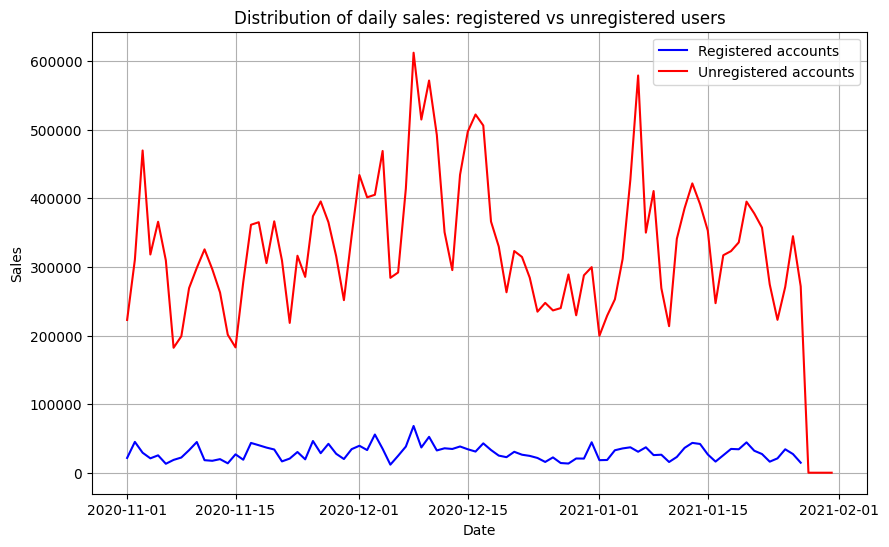

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(registered_account_sales,
             x = 'date',
             y = 'price',
             label = 'Registered accounts',
             color = 'blue'
            )
sns.lineplot(unregistered_account_sales,
             x = 'date',
             y = 'price',
             label = 'Unregistered accounts',
             color = 'red')
plt.title('Distribution of daily sales: registered vs unregistered users')
plt.ylabel('Sales')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
from scipy.stats import shapiro

# Normality test
_, p_value_norm_registered = shapiro(registered_account_sales['price'])
_, p_value_norm_unregistered = shapiro(unregistered_account_sales['price'])
print(f"p-value of normality test for registered accounts: {p_value_norm_registered}")
print(f"p-value of normality test for unregistered accounts: {p_value_norm_unregistered}")


p-value of normality test for registered accounts: 0.007295139880540744
p-value of normality test for unregistered accounts: 0.0012184604855253293


Since:
- distributions are not normal
- samples are independent
- data are quantitative
- sample sizes are the same (by dates)

Correct test: Mann–Whitney U test

In [ ]:
from scipy.stats import mannwhitneyu

# Perform Mann-Whitney U test
u_stat, p_value = mannwhitneyu(registered_account_sales['price'], unregistered_account_sales['price'])
print(f"U-statistic: {u_stat}, p-value: {p_value}")

U-statistic: 352.0, p-value: 3.8805185465235906e-26


Sales of registered and unregistered users differ significantly.
Both samples are not normally distributed, so the non-parametric Mann–Whitney U test was applied.
The resulting Mann–Whitney U test p-value 3.9e-26 indicates a high statistical significance of the difference between the groups.
Unregistered users generate significantly higher daily sales.

##Sessions in different traffic channels

In [ ]:
df['traffic_channel'].value_counts()

,count
traffic_channel,
Organic Search,124425
Paid Search,94341
Direct,81382
Social Search,27914
Undefined,21483


Undefined channel is smaller than the other 4 main channels but it represemts a big chunk of sessions across the all traffic channels, so it would be better to keep this data in our research.

In [ ]:
from scipy.stats import shapiro

#grouping sessions data by traffic channel
sessions_by_traffic_channel = (
    df.groupby(['date','traffic_channel'])['session_id']
      .nunique()
      .reset_index(name='sessions')
    )

#creating separate dataframes for each channel
dfs = {}

for channel in sessions_by_traffic_channel['traffic_channel'].unique():
  dfs[channel] = sessions_by_traffic_channel[sessions_by_traffic_channel['traffic_channel'] == channel].reset_index(drop = True).drop(columns = 'traffic_channel')

#normality test
normality_results = {}
for channel in dfs:
  _, p_value = shapiro(dfs[channel]['sessions'])
  normality_results[channel] = p_value

normality_results

{'Direct': np.float64(0.034278771626201326),
 'Organic Search': np.float64(0.012271774671209374),
 'Paid Search': np.float64(0.010833125972481636),
 'Social Search': np.float64(0.14127184979117535),
 'Undefined': np.float64(0.054564615910193105)}

After testing the session data for normality, where a **P value < 0.05** means that the data is not normally distributed, only 2 out of 5 channels are normally distributed. Therefore, the best method to prove statistically significant differences across all channels is the "Kruskal-Wallis test".

In [ ]:
from scipy.stats import kruskal

# Perform the Kruskal-Wallis test
_, p_value = kruskal(*[dfs[channel]['sessions'] for channel in dfs])
print(f"Kruskal-Wallis test P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print('There is a significant difference in number of sessions in different traffic channels.')
else:
    print('There is  no significant difference in number of sessions in different traffic channels.')


Kruskal-Wallis test P-value: 1.397036102599359e-78
There is a significant difference in number of sessions in different traffic channels.


##Proportion test of Organic Search sessions in Europe and America

In [ ]:
#calculations of entry data for proportion test
total_sessions_america = df.loc[df['continent'] == 'Americas', 'session_id'].nunique()
total_sessions_europe = df.loc[df['continent'] == 'Europe', 'session_id'].nunique()

organic_sessions_america = df.loc[(df['continent'] == 'Americas') & (df['traffic_channel'] == 'Organic Search'), 'session_id'].nunique()
organic_sessions_europe = df.loc[(df['continent'] == 'Europe') & (df['traffic_channel'] == 'Organic Search'), 'session_id'].nunique()

#proportion test (z-test)
import statsmodels.api as sm

_, p_value = sm.stats.proportions_ztest(
    [organic_sessions_america, organic_sessions_europe],
    [total_sessions_america, total_sessions_europe]
    )

print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("There is a statistically significant difference in organic sessions between America and Europe.")
else:
    print("No statistically significant difference in organic sessions between America and Europe.")


P-value: 0.7721879690501752
No statistically significant difference in organic sessions between America and Europe.


The share of organic sessions in Europe and America is not statistically different.
The two-proportion z-test gave a p-value ≈ 0.77, which is significantly higher than the 0.05 threshold.
This means that the observed difference is random and has no statistical confirmation.

#[Tableau Dashboard](https://public.tableau.com/views/BusinessPerformanceOverview_17775798601180/BusinessPerformanceOverviewSalesandTraffic?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

In [ ]:
# Exporting data to create a Dashboard in Tableau

from google.colab import drive

drive.mount("/content/drive")

df.to_csv("/content/drive/MyDrive/Mate_academy/Tasks/Portfolio/Project1/dashboard_data.csv", index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#[Summary](https://docs.google.com/document/d/14rW9SRstulkQe5jVsL9DH_TjLmt6C4W9o-5rBRxlYqY/edit?usp=sharing)